In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
ads_data=pd.read_csv('/content/Social_Network_Ads.csv')
ads_data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
ads_data.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
ads_data['User ID'].unique()

array([15624510, 15810944, 15668575, 15603246, 15804002, 15728773,
       15598044, 15694829, 15600575, 15727311, 15570769, 15606274,
       15746139, 15704987, 15628972, 15697686, 15733883, 15617482,
       15704583, 15621083, 15649487, 15736760, 15714658, 15599081,
       15705113, 15631159, 15792818, 15633531, 15744529, 15669656,
       15581198, 15729054, 15573452, 15776733, 15724858, 15713144,
       15690188, 15689425, 15671766, 15782806, 15764419, 15591915,
       15772798, 15792008, 15715541, 15639277, 15798850, 15776348,
       15727696, 15793813, 15694395, 15764195, 15744919, 15671655,
       15654901, 15649136, 15775562, 15807481, 15642885, 15789109,
       15814004, 15673619, 15595135, 15583681, 15605000, 15718071,
       15679760, 15654574, 15577178, 15595324, 15756932, 15726358,
       15595228, 15782530, 15592877, 15651983, 15746737, 15774179,
       15667265, 15655123, 15595917, 15668385, 15709476, 15711218,
       15798659, 15663939, 15694946, 15631912, 15768816, 15682

In [ ]:
#Dropping User ID as all its values are unique
ads_data.drop('User ID',axis=1,inplace=True)

In [ ]:
ads_data.columns

Index(['Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [ ]:
#Checking Null Value
ads_data.isna().sum()

,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
ads_data.dtypes

,0
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


In [ ]:
ads_data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
#One hot encoding gender column
ads_data=pd.get_dummies(ads_data,prefix='Gender',dtype=int)
ads_data.head()

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,0,1
1,35,20000,0,0,1
2,26,43000,0,1,0
3,27,57000,0,1,0
4,19,76000,0,0,1


In [ ]:
ads_data['Purchased'].unique()

array([0, 1])

In [ ]:
ads_data['Purchased'].value_counts(normalize=True)
#Since no of 0s and 1s arenot same we call this as imbalanced data

,proportion
Purchased,
0,0.6425
1,0.3575


{'whiskers': [<matplotlib.lines.Line2D at 0x7c038e677dd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7c038e6a8380>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c038e677b30>],
 'medians': [<matplotlib.lines.Line2D at 0x7c038e6a87d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c038e6a8ad0>],
 'means': []}

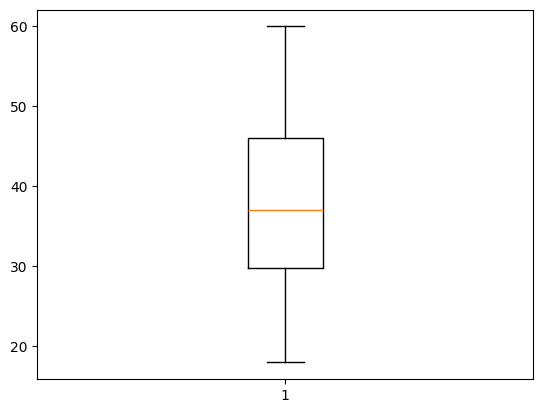

In [ ]:
#Cheking outlier
plt.boxplot(ads_data['Age'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7c038e639580>,
 'caps': [<matplotlib.lines.Line2D at 0x7c038e639df0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c038e63a7e0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c038e63b890>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c038e63b710>],
 'means': []}

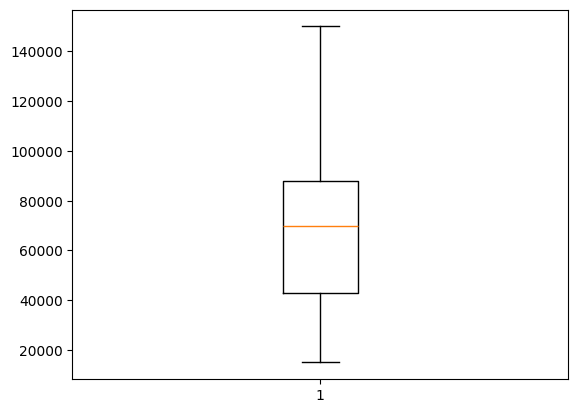

In [ ]:
plt.boxplot(ads_data['EstimatedSalary'])



In [ ]:
#Target Splitting
y=ads_data['Purchased']
x=ads_data.drop('Purchased',axis=1)


In [ ]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression


In [ ]:
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(x_train,y_train)
y_pred_lr_model=lr_model.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score
print(accuracy_score(y_test,y_pred_lr_model))
print(confusion_matrix(y_test,y_pred_lr_model))
print(recall_score(y_test,y_pred_lr_model))
print(f1_score(y_test,y_pred_lr_model))
print(precision_score(y_test,y_pred_lr_model))

0.8875
[[50  2]
 [ 7 21]]
0.75
0.8235294117647058
0.9130434782608695


KNN

In [ ]:
#KNN
#finding the optimum k value

from sklearn.neighbors import KNeighborsClassifier
acc_score=[]
for k in range(3,10):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train,y_train)
  y_pred_knn=knn.predict(x_test)
  acc=accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

acc_score


[0.8, 0.8, 0.825, 0.775, 0.8125, 0.775, 0.8]

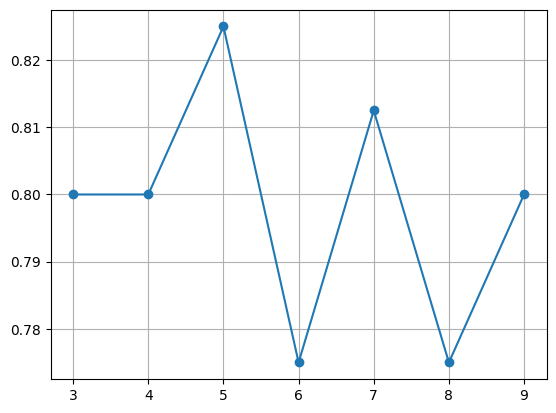

In [ ]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.grid()

In [ ]:
#optimum k value is 5 ( ACC HIGHEST)
#Train KNN model for k=5
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)
print(confusion_matrix(y_test,y_pred_knn))
print(accuracy_score(y_test,y_pred_knn))
print(recall_score(y_test,y_pred_knn))
print(f1_score(y_test,y_pred_knn))
print(precision_score(y_test,y_pred_knn))


[[46  6]
 [ 8 20]]
0.825
0.7142857142857143
0.7407407407407407
0.7692307692307693


In [ ]:
x.describe()

,Age,EstimatedSalary,Gender_Female,Gender_Male
count,400.000000,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.510000,0.490000
std,10.482877,34096.960282,0.500526,0.500526
min,18.000000,15000.000000,0.000000,0.000000
25%,29.750000,43000.000000,0.000000,0.000000
50%,37.000000,70000.000000,1.000000,0.000000
75%,46.000000,88000.000000,1.000000,1.000000
max,60.000000,150000.000000,1.000000,1.000000


In [ ]:
#Do scaling on numerical value
x_scaled_data=x.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
for i in ['Age','EstimatedSalary']:
  x_scaled_data[i]=scaler.fit_transform(x_scaled_data[[i]])

In [ ]:
x.describe()

,Age,EstimatedSalary,Gender_Female,Gender_Male
count,400.000000,400.000000,400.000000,400.000000
mean,0.467976,0.405500,0.510000,0.490000
std,0.249592,0.252570,0.500526,0.500526
min,0.000000,0.000000,0.000000,0.000000
25%,0.279762,0.207407,0.000000,0.000000
50%,0.452381,0.407407,1.000000,0.000000
75%,0.666667,0.540741,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
#train test split for scaled data
x_train_scaled,x_test_scaled,y_train_scaled,y_test_scaled=train_test_split(x_scaled_data,y,test_size=0.2,random_state=42)

In [ ]:
#Logistic Regression model with scaled data
lr_model_scaled=LogisticRegression(max_iter=1000)
lr_model_scaled.fit(x_train_scaled,y_train_scaled)
y_pred_lr_model_scaled=lr_model_scaled.predict(x_test_scaled)

In [ ]:
print(accuracy_score(y_test_scaled,y_pred_lr_model_scaled))
print(confusion_matrix(y_test_scaled,y_pred_lr_model_scaled))
print(recall_score(y_test_scaled,y_pred_lr_model_scaled))
print(f1_score(y_test_scaled,y_pred_lr_model_scaled))
print(precision_score(y_test_scaled,y_pred_lr_model_scaled))

0.875
[[51  1]
 [ 9 19]]
0.6785714285714286
0.7916666666666666
0.95


In [ ]:
#KNN
#finding the optimum k value fopr scaled

acc_score=[]
for k in range(3,10):
  knn_scaled=KNeighborsClassifier(n_neighbors=k)
  knn_scaled.fit(x_train_scaled,y_train_scaled)
  y_pred_knn_scaled=knn_scaled.predict(x_test_scaled)
  acc=accuracy_score(y_test_scaled,y_pred_knn_scaled)
  acc_score.append(acc)

acc_score

[0.9125, 0.9125, 0.925, 0.9375, 0.925, 0.925, 0.925]

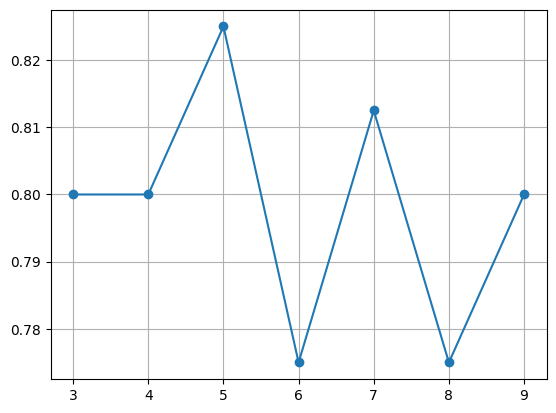

In [ ]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.grid()

In [ ]:
#optimum k value is 6 ( ACC HIGHEST)
#Train KNN model for k=6
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(x_train_scaled,y_train_scaled)
y_pred_knn_scaled=knn.predict(x_test_scaled)
print(confusion_matrix(y_test_scaled,y_pred_knn_scaled))
print(accuracy_score(y_test_scaled,y_pred_knn_scaled))
print(recall_score(y_test_scaled,y_pred_knn_scaled))
print(f1_score(y_test_scaled,y_pred_knn_scaled))
print(precision_score(y_test_scaled,y_pred_knn_scaled))

[[49  3]
 [ 2 26]]
0.9375
0.9285714285714286
0.9122807017543859
0.896551724137931


In [ ]:
#SVM
from sklearn.svm import SVC

In [ ]:
#linear
svmclf_linear=SVC(kernel='linear')
svmclf_linear.fit(x_train,y_train)
y_pred_svmclf_linear=svmclf_linear.predict(x_test)
print(confusion_matrix(y_test,y_pred_svmclf_linear))
print(accuracy_score(y_test,y_pred_svmclf_linear))
print(recall_score(y_test,y_pred_svmclf_linear))
print(f1_score(y_test,y_pred_svmclf_linear))
print(precision_score(y_test,y_pred_svmclf_linear))

[[48  4]
 [ 9 19]]
0.8375
0.6785714285714286
0.7450980392156863
0.8260869565217391


In [ ]:
#Poly
svmclf_linear=SVC(kernel='poly')
svmclf_linear.fit(x_train,y_train)
y_pred_svmclf_poly=svmclf_linear.predict(x_test)
print(confusion_matrix(y_test,y_pred_svmclf_poly))
print(accuracy_score(y_test,y_pred_svmclf_poly))
print(recall_score(y_test,y_pred_svmclf_poly))
print(f1_score(y_test,y_pred_svmclf_poly))
print(precision_score(y_test,y_pred_svmclf_poly))


[[49  3]
 [19  9]]
0.725
0.32142857142857145
0.45
0.75


In [ ]:
#rbf
svmclf_linear=SVC(kernel='rbf')
svmclf_linear.fit(x_train,y_train)
y_pred_svmclf_rbf=svmclf_linear.predict(x_test)
print(confusion_matrix(y_test,y_pred_svmclf_rbf))
print(accuracy_score(y_test,y_pred_svmclf_rbf))
print(recall_score(y_test,y_pred_svmclf_rbf))
print(f1_score(y_test,y_pred_svmclf_rbf))
print(precision_score(y_test,y_pred_svmclf_rbf))


[[49  3]
 [18 10]]
0.7375
0.35714285714285715
0.4878048780487805
0.7692307692307693


In [ ]:
#linear_scaled
svmclf_linear_scaled=SVC(kernel='linear')
svmclf_linear_scaled.fit(x_train_scaled,y_train_scaled)
y_pred_svmclf_linear=svmclf_linear_scaled.predict(x_test_scaled)
print(confusion_matrix(y_test_scaled,y_pred_svmclf_linear))
print(accuracy_score(y_test_scaled,y_pred_svmclf_linear))
print(recall_score(y_test_scaled,y_pred_svmclf_linear))
print(f1_score(y_test_scaled,y_pred_svmclf_linear))
print(precision_score(y_test_scaled,y_pred_svmclf_linear))

[[51  1]
 [ 9 19]]
0.875
0.6785714285714286
0.7916666666666666
0.95


In [ ]:
#Poly_scaled
svmclf_poly_scaled=SVC(kernel='poly')
svmclf_poly_scaled.fit(x_train_scaled,y_train_scaled)
y_pred_svmclf_poly=svmclf_poly_scaled.predict(x_test_scaled)
print(confusion_matrix(y_test_scaled,y_pred_svmclf_poly))
print(accuracy_score(y_test_scaled,y_pred_svmclf_poly))
print(recall_score(y_test_scaled,y_pred_svmclf_poly))
print(f1_score(y_test_scaled,y_pred_svmclf_poly))
print(precision_score(y_test_scaled,y_pred_svmclf_poly))

[[48  4]
 [ 2 26]]
0.925
0.9285714285714286
0.896551724137931
0.8666666666666667


In [ ]:
#rbf_scaled
svmclf_rbf_scaled=SVC(kernel='rbf')
svmclf_rbf_scaled.fit(x_train_scaled,y_train_scaled)
y_pred_svmclf_rbf_scaled=svmclf_rbf_scaled.predict(x_test_scaled)
print(confusion_matrix(y_test_scaled,y_pred_svmclf_rbf_scaled))
print(accuracy_score(y_test_scaled,y_pred_svmclf_rbf_scaled))
print(recall_score(y_test_scaled,y_pred_svmclf_rbf_scaled))
print(f1_score(y_test_scaled,y_pred_svmclf_rbf_scaled))
print(precision_score(y_test_scaled,y_pred_svmclf_rbf_scaled))

[[49  3]
 [ 3 25]]
0.925
0.8928571428571429
0.8928571428571429
0.8928571428571429


In [ ]:
#Decision Trees
from sklearn.tree import DecisionTreeClassifier
dt_clf=DecisionTreeClassifier(criterion='entropy')
dt_clf.fit(x_train,y_train)
y_pred_dt=dt_clf.predict(x_test)
print(confusion_matrix(y_test,y_pred_dt))
print(accuracy_score(y_test,y_pred_dt))
print(recall_score(y_test,y_pred_dt))
print(f1_score(y_test,y_pred_dt))
print(precision_score(y_test,y_pred_dt))

[[46  6]
 [ 6 22]]
0.85
0.7857142857142857
0.7857142857142857
0.7857142857142857


In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
rf_clf=RandomForestClassifier()
rf_clf.fit(x_train,y_train)
y_pred_rf=rf_clf.predict(x_test)
print(confusion_matrix(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_rf))
print(recall_score(y_test,y_pred_rf))
print(f1_score(y_test,y_pred_rf))
print(precision_score(y_test,y_pred_rf))

[[47  5]
 [ 3 25]]
0.9
0.8928571428571429
0.8620689655172413
0.8333333333333334
